# 응용동역학 3주차 실습 — 탄성응답스펙트럼

**목표** (약 25분)
1. 1자유도계를 직접 풀어 응답스펙트럼을 만든다.
2. 설계스펙트럼(KDS 4구간 형태)을 그리고 T₀·T_S를 확인한다.
3. 건물 주기를 스펙트럼에 얹어 어느 구간인지 판단한다.
4. 감쇠비를 바꿔 스펙트럼이 어떻게 내려가는지 본다.

> 지진파는 **교육용 합성파**다(실측 기록 아님). 설계값은 강의 덱 p.39 값(S_DS = 0.37, S_D1 = 0.16)을 쓴다.
> 실행: Colab 또는 로컬 Jupyter. 필요 패키지는 `numpy`, `matplotlib`뿐이다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
G = 9.81  # m/s^2

## 0. 도구 — 1자유도계 풀이 (Newmark 평균가속도법)

운동방정식: $\ddot u + 2\zeta\omega\dot u + \omega^2 u = -\ddot u_g$

함수는 상대변위 $u$, 상대속도 $\dot u$, 절대가속도 $\ddot u + \ddot u_g$를 돌려준다.

In [2]:
def sdof(ag, T, zeta, dt):
    """Unit-mass SDOF, Newmark average acceleration (unconditionally stable).
    ag: ground acceleration [m/s^2]. Returns u [m], v [m/s], a_abs [m/s^2]."""
    w = 2 * np.pi / T
    k, c = w**2, 2 * zeta * w
    n = ag.size
    u, v, a = np.zeros(n), np.zeros(n), np.zeros(n)
    a[0] = -ag[0]
    kh = k + 2 * c / dt + 4 / dt**2
    for i in range(n - 1):
        dp = -(ag[i + 1] - ag[i]) + (4 / dt + 2 * c) * v[i] + 2 * a[i]
        du = dp / kh
        dv = 2 * du / dt - 2 * v[i]
        u[i + 1], v[i + 1] = u[i] + du, v[i] + dv
        a[i + 1] = -ag[i + 1] - c * v[i + 1] - k * u[i + 1]
    return u, v, a + ag

### 0-1. 교육용 합성 지진파

백색잡음 → Kanai-Tajimi 지반필터(ω_g = 15 rad/s, ζ_g = 0.6) → 포락선 → PGA 0.20g로 스케일.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50977 (\N{HANGUL SYLLABLE YUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

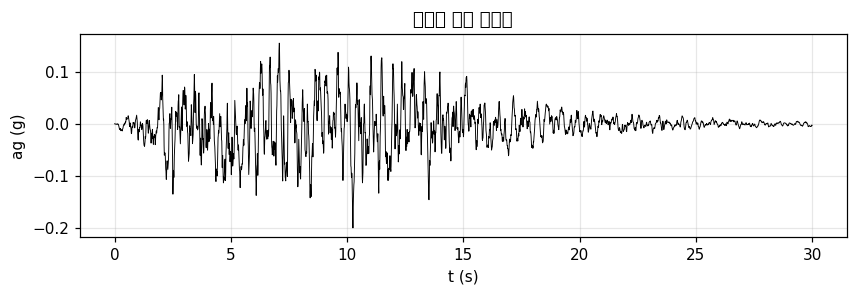

In [3]:
rng = np.random.default_rng(7)
dt, dur = 0.01, 30.0
t = np.arange(0, dur, dt)
wg, zg = 15.0, 0.6
ug, vg, _ = sdof(rng.standard_normal(t.size), 2 * np.pi / wg, zg, dt)
ag = -(2 * zg * wg * vg + wg**2 * ug)
env = np.clip(t / 3, 0, 1) * np.where(t > 12, np.exp(-0.18 * (t - 12)), 1.0)
PGA_g = 0.20
ag = ag * env
ag = ag / np.abs(ag).max() * PGA_g * G   # m/s^2
assert np.isclose(np.abs(ag).max() / G, PGA_g)

plt.figure(figsize=(9, 2.4)); plt.plot(t, ag / G, lw=0.6, color="k")
plt.xlabel("t (s)"); plt.ylabel("ag (g)"); plt.title("교육용 합성 지진파"); plt.show()

## 1. 예제 1 — 응답스펙트럼 만들기

주기만 다른 1자유도계 3개를 같은 지진파에 놓고 최대변위를 찾는다.

In [4]:
for T in [0.3, 1.0, 2.5]:
    u, _, _ = sdof(ag, T, 0.05, dt)
    D = np.abs(u).max()
    PSA = (2 * np.pi / T) ** 2 * D / G
    print(f"T = {T:4.1f} s   Dmax = {D*100:6.2f} cm   PSa = ω²·D = {PSA:.3f} g")

T =  0.3 s   Dmax =   0.88 cm   PSa = ω²·D = 0.395 g
T =  1.0 s   Dmax =   4.28 cm   PSa = ω²·D = 0.172 g
T =  2.5 s   Dmax =  21.45 cm   PSa = ω²·D = 0.138 g


이 최대값을 모든 주기에 대해 모으면 응답스펙트럼이다.

/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 49549 (\N{HANGUL SYLLABLE SOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_675/1126257695.py:16: UserWarning: Glyph 54169 (\N{HANGUL S

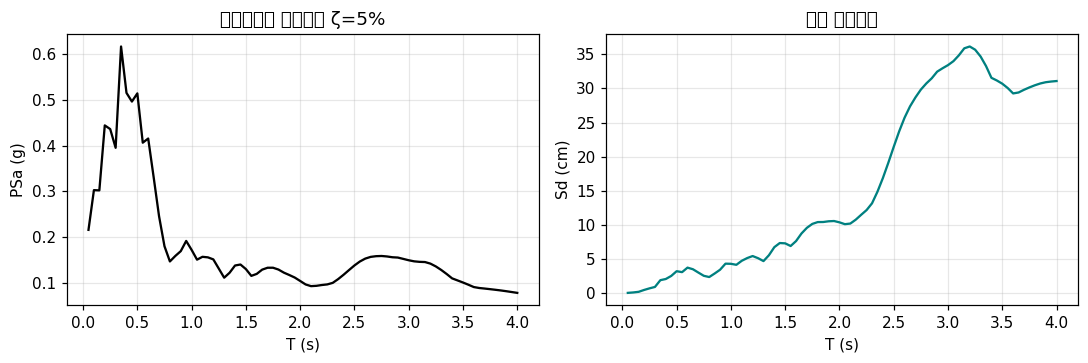

In [5]:
periods = np.arange(0.05, 4.01, 0.05)

def spectrum(ag, zeta, dt, periods=periods):
    """Returns Sd [m], PSa [g], Sa_abs [g]."""
    Sd, PSa, Sa = [], [], []
    for T in periods:
        u, _, aabs = sdof(ag, T, zeta, dt)
        D = np.abs(u).max()
        Sd.append(D); PSa.append((2*np.pi/T)**2 * D / G); Sa.append(np.abs(aabs).max() / G)
    return np.array(Sd), np.array(PSa), np.array(Sa)

Sd5, PSa5, Sa5 = spectrum(ag, 0.05, dt)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(periods, PSa5, "k"); ax[0].set(xlabel="T (s)", ylabel="PSa (g)", title="유사가속도 스펙트럼 ζ=5%")
ax[1].plot(periods, Sd5 * 100, "teal"); ax[1].set(xlabel="T (s)", ylabel="Sd (cm)", title="변위 스펙트럼")
plt.tight_layout(); plt.show()

**생각해 볼 질문**: T → 0이면 PSa는 어디로 가나? (힌트: PGA) T가 매우 길면 Sd는?

In [6]:
print(f"PSa(T=0.05s) = {PSa5[0]:.3f} g   vs   PGA = {PGA_g} g")

PSa(T=0.05s) = 0.216 g   vs   PGA = 0.2 g


## 2. 예제 2 — 설계스펙트럼과 절점

KDS 4구간 형태: 0~T₀ 상승, T₀~T_S 평탄(S_DS), T_S~T_L 하강(S_D1/T), T_L 이후 S_D1·T_L/T².

> T_L 값은 KDS 41 17 00 원문 확인 필요. 아래는 **임시값**이며 바꿔 가며 보라.

T_S = 0.432 s,  T0 = 0.086 s


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


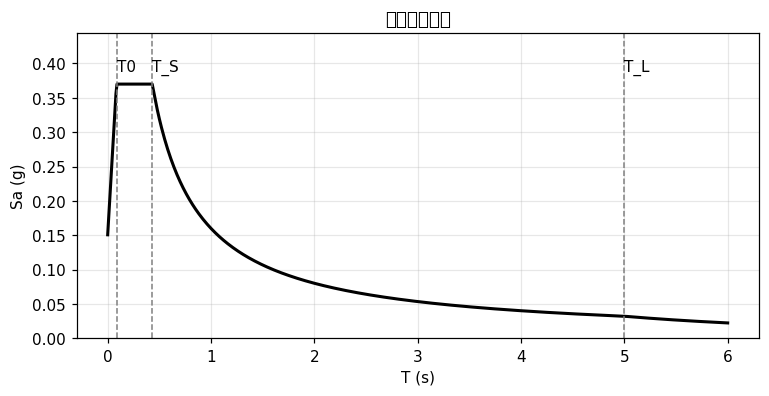

In [7]:
S_DS, S_D1 = 0.37, 0.16     # g, lecture deck p.39
T_L = 5.0                    # s, PLACEHOLDER - verify against KDS 41 17 00

def design_spectrum(T, S_DS, S_D1, T_L):
    T = np.asarray(T, dtype=float)
    Ts = S_D1 / S_DS
    T0 = 0.2 * Ts
    return np.select(
        [T < T0, T <= Ts, T <= T_L],
        [S_DS * (0.4 + 0.6 * T / T0), S_DS, S_D1 / np.maximum(T, 1e-9)],
        S_D1 * T_L / T**2)

Ts, T0 = S_D1 / S_DS, 0.2 * S_D1 / S_DS
print(f"T_S = {Ts:.3f} s,  T0 = {T0:.3f} s")
TT = np.linspace(0.001, 6, 600)
plt.figure(figsize=(8, 3.6))
plt.plot(TT, design_spectrum(TT, S_DS, S_D1, T_L), "k", lw=2)
for x, lab in [(T0, "T0"), (Ts, "T_S"), (T_L, "T_L")]:
    plt.axvline(x, ls="--", lw=1, color="gray"); plt.text(x, S_DS * 1.05, lab)
plt.xlabel("T (s)"); plt.ylabel("Sa (g)"); plt.title("설계스펙트럼"); plt.ylim(0, S_DS * 1.2); plt.show()

**실습 2-1**: S_D1만 0.16 → 0.30으로 키워 보라(연약지반 가정). T_S는 어떻게 움직이나?

In [8]:
# TODO: S_D1 값을 바꿔 다시 그려 보세요
S_D1_soft = 0.30
print(f"T_S: {S_D1/S_DS:.3f} s  ->  {S_D1_soft/S_DS:.3f} s")

T_S: 0.432 s  ->  0.811 s


## 3. 예제 3 — 건물 주기를 스펙트럼에 얹기

RC 모멘트골조 약산식 $T_a = 0.0466\,h_n^{0.9}$ (강의 덱 p.39, 층고 3.5 m 가정).
다른 구조형식 계수는 KDS 7.2.4 표에서 직접 확인해 넣을 것.

  5층  h=  17.5 m  Ta= 0.61 s  Sa=0.261 g  1/T(속도)
 10층  h=  35.0 m  Ta= 1.14 s  Sa=0.140 g  1/T(속도)
 20층  h=  70.0 m  Ta= 2.13 s  Sa=0.075 g  1/T(속도)
 40층  h= 140.0 m  Ta= 3.98 s  Sa=0.040 g  1/T(속도)


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52789 (\N{HANGUL SYLLABLE CEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


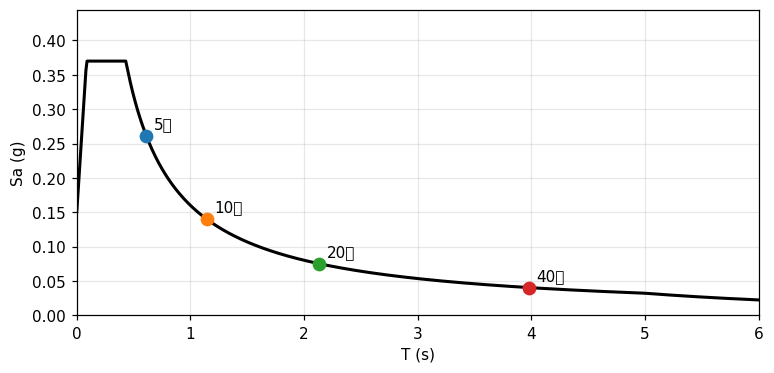

In [9]:
Ct, x = 0.0466, 0.9      # RC moment frame (deck p.39)
story_h = 3.5            # m
rows = []
for n in [5, 10, 20, 40]:
    h = n * story_h
    Ta = Ct * h**x
    Sa = float(design_spectrum(Ta, S_DS, S_D1, T_L))
    zone = "평탄부(가속도)" if Ta <= Ts else ("1/T(속도)" if Ta <= T_L else "1/T²(변위)")
    rows.append((n, h, Ta, Sa, zone))
    print(f"{n:3d}층  h={h:6.1f} m  Ta={Ta:5.2f} s  Sa={Sa:.3f} g  {zone}")

plt.figure(figsize=(8, 3.6))
plt.plot(TT, design_spectrum(TT, S_DS, S_D1, T_L), "k", lw=2)
for n, h, Ta, Sa, _ in rows:
    plt.plot(Ta, Sa, "o", ms=8); plt.annotate(f"{n}층", (Ta, Sa), xytext=(5, 5), textcoords="offset points")
plt.xlabel("T (s)"); plt.ylabel("Sa (g)"); plt.xlim(0, 6); plt.ylim(0, S_DS * 1.2); plt.show()

**실습 3-1**: 몇 층부터 평탄부를 벗어나는가? 지반을 바꾸면(실습 2-1의 S_D1) 그 층수는?

**실습 3-2 (고차모드 미리보기)**: 균일 전단빌딩에서 $T_2 \approx T_1/3$으로 가정하면, 20층의 2차 모드는 어느 구간에 놓이나?

In [10]:
# TODO: 20층의 T1, T2(=T1/3 가정)를 스펙트럼에 표시해 보세요
T1 = Ct * (20 * story_h) ** x
T2 = T1 / 3
for name, T in [("T1", T1), ("T2", T2)]:
    print(name, f"{T:.2f} s", "평탄부" if T <= Ts else "하강부")

T1 2.13 s 하강부
T2 0.71 s 하강부


## 4. 예제 4 — 감쇠비를 바꾸면 (점성댐퍼의 원리)

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49632 (\N{HANGUL SYLLABLE SOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


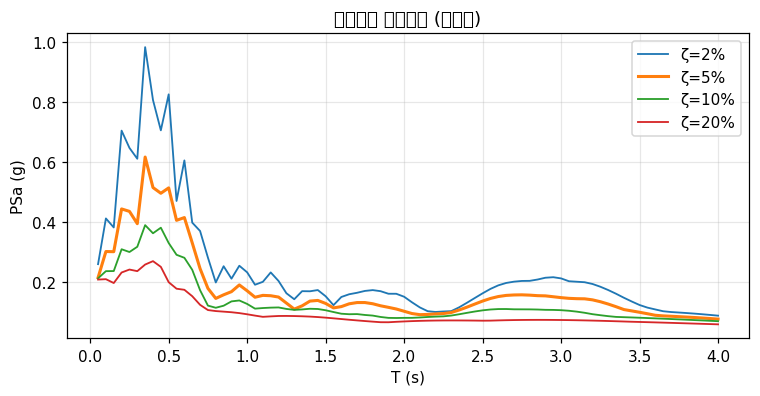

T=0.5s  PSa(20%)/PSa(5%) = 0.391
T=1.0s  PSa(20%)/PSa(5%) = 0.547
T=2.0s  PSa(20%)/PSa(5%) = 0.675


In [11]:
plt.figure(figsize=(8, 3.6))
res = {}
for z in [0.02, 0.05, 0.10, 0.20]:
    _, psa, sa = spectrum(ag, z, dt)
    res[z] = (psa, sa)
    plt.plot(periods, psa, lw=2 if z == 0.05 else 1.2, label=f"ζ={z:.0%}")
plt.xlabel("T (s)"); plt.ylabel("PSa (g)"); plt.legend(); plt.title("감쇠비별 스펙트럼 (합성파)"); plt.show()

for T in [0.5, 1.0, 2.0]:
    i = np.argmin(abs(periods - T))
    print(f"T={T}s  PSa(20%)/PSa(5%) = {res[0.20][0][i] / res[0.05][0][i]:.3f}")

**실습 4-1 — 유사가속도 vs 실제 가속도**: 감쇠 5%와 20%에서 PSa/Sa 비를 비교하라.
고감쇠 건물의 층가속도를 PSa로 추정해도 되는가?

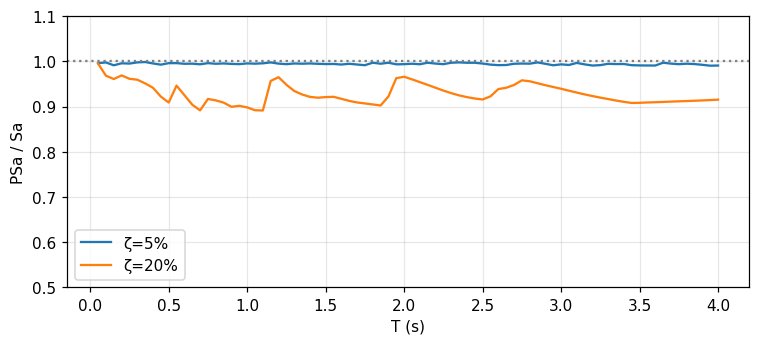

In [12]:
plt.figure(figsize=(8, 3.2))
for z in [0.05, 0.20]:
    psa, sa = res[z]
    plt.plot(periods, psa / sa, label=f"ζ={z:.0%}")
plt.axhline(1, color="gray", ls=":"); plt.ylim(0.5, 1.1)
plt.xlabel("T (s)"); plt.ylabel("PSa / Sa"); plt.legend(); plt.show()

## 5. 도전 과제 (선택)

1. `rng` seed를 바꿔 합성파 5개를 만들고 평균 스펙트럼을 그려라. 개별 곡선과 평균은 무엇이 다른가? (덱 p.23)
2. 합성파 스펙트럼(ζ=5%)을 설계스펙트럼과 겹쳐 그리고, 0.2T₁~1.5T₁ 구간에서 평균이 설계값 이상이 되도록 하는 스케일계수를 구하라. (NLTHA 지진파 스케일링의 축소판 — 실제 기준 조항은 확인할 것)
3. 실측 기록(PEER NGA 등)을 불러와 같은 함수로 스펙트럼을 그려 보라. `dt`가 다르면 무엇을 바꿔야 하나?